In [57]:
#importing necessary libraries
import pandas as pd

In [58]:
df = pd.read_csv("smart_traffic_system_data.csv")

In [59]:
df.head(5)

,Average_Speed,Vehicle_Count,Time_of_Day,Day_of_Week,Congestion
0,54.967142,15,21,4,0
1,48.617357,22,8,1,1
2,56.476885,23,6,4,0
3,65.230299,18,20,0,0
4,47.658466,21,23,0,0


In [60]:
df.shape

(1000, 5)

In [61]:
df.isnull().sum()

Average_Speed    0
Vehicle_Count    0
Time_of_Day      0
Day_of_Week      0
Congestion       0
dtype: int64

In [62]:
df.describe()

,Average_Speed,Vehicle_Count,Time_of_Day,Day_of_Week,Congestion
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,50.193321,19.910000,11.827000,2.964000,0.342000
std,9.792159,4.577429,6.748527,2.054002,0.474617
min,17.587327,7.000000,0.000000,0.000000,0.000000
25%,43.524097,17.000000,6.000000,1.000000,0.000000
50%,50.253006,20.000000,12.000000,3.000000,0.000000
75%,56.479439,23.000000,18.000000,5.000000,1.000000
max,88.527315,36.000000,23.000000,6.000000,1.000000


In [7]:
#### importing sklearn libraries for feature engineering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [63]:
X = df.drop("Congestion", axis=1)
y=df['Congestion']

In [65]:
## splitting our data set 
X_train,X_test, y_train,y_test = train_test_split(X,y, random_state=42, test_size=0.2)

In [10]:
scaler = StandardScaler()

In [66]:
## it ensures that the model is notbiased by the scale of any feature.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.fit_transform(X_test)

In [67]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [68]:
# neural network initialization
model = Sequential(
    [
        Dense(
            128, activation = "relu",
            input_shape=(X_train_scaled.shape[1],)
        ),
        Dense(
            64, activation = "relu"
        ),
        Dense(
            32, activation = "relu"
        ),
        Dense(
            1, activation = "sigmoid"
        )
    ]
)

C:\Users\M.I.S SITHLTD\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
# compiling our neural network
model.compile(
    optimizer="adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

In [70]:
# training our neural network
model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.6356 - loss: 0.6641 - val_accuracy: 0.8000 - val_loss: 0.5560
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7650 - loss: 0.5587 - val_accuracy: 0.8000 - val_loss: 0.4746
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8008 - loss: 0.4737 - val_accuracy: 0.8125 - val_loss: 0.4381
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7881 - loss: 0.4655 - val_accuracy: 0.8313 - val_loss: 0.4159
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8189 - loss: 0.4354 - val_accuracy: 0.8438 - val_loss: 0.4162
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8319 - loss: 0.4006 - val_accuracy: 0.8562 - val_loss: 0.3909
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8253 - loss: 0.3868 - val_accuracy: 0.8188 - val_loss: 0.3791
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8253 - loss: 0.4007 - val_accuracy: 0.8

##  Model Evaluation with k-Fold Cross-Validation

In [73]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

In [75]:
#Cross-validation Setup and Execution
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
score = []

In [76]:
X_scaled_full = scaler.fit_transform(X)
y_full =y.values

### Configured to halt training if there is no improvement in validation loss after five epochs, ensuring efficient training and avoidance of overfitting by restoring the best model weights.

In [78]:
early_stopping = EarlyStopping(
    monitor = 'val_loss', patience=5, restore_best_weights=True
)

In [79]:
#Cross-validation Setup and Execution
for train , test in kfold.split(X_scaled_full, y_full):
    model =  Sequential(
    [
        Dense(
            64, activation = "relu",
            input_shape=(X_scaled_full.shape[1],)
        ),
        Dropout(0.4),
        Dense(
            32, activation = "relu"
        ),
        Dropout(0.4),
        Dense(
            16, activation = "relu"
        ),
        Dense(
            1, activation = "sigmoid"
        )])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    model.fit(X_scaled_full[train], y_full[train],
             epochs=150, batch_size=32, verbose=0, 
             validation_split=0.2, callbacks=[early_stopping])
    acc = model.evaluate(X_scaled_full[test], y_full[test], verbose=0)
    score.append(acc)
                        

C:\Users\M.I.S SITHLTD\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [80]:
#average accuracy
avg_acc = np.mean(score)

In [81]:
avg_acc

0.5958767592906952

In [82]:
#defining hyperparamter to explore

batch_sizes=[16,32,64]
epochs_list=[50,100]
optimizers=['adam', 'rmsprop']
activations=['relu', 'tanh']

In [83]:
# initialize variables to store the best model and parameters
best_score = 0
best_params ={}

In [84]:
#loop over hyperparamters
for batch_size in batch_sizes:
    for epochs in epochs_list:
        for optimizer in optimizers:
            for activation in activations:

                model = Sequential([
                    Dense(128, activation = activation,
                          input_shape = (X_scaled_full.shape[1],)),
                    Dense(64, activation=activation),
                    Dense(32, activation=activation),
                    Dense(1, activation='sigmoid')
                ])
                model.compile(optimizer = optimizer,
                             loss = 'binary_crossentropy',
                             metrics = ['accuracy'])
                history = model.fit(X_scaled_full, y_full,
                                   epochs = epochs,
                                   batch_size=batch_size,
                                   verbose=0,
                                   validation_split=0.2)
                val_accuracy = np.max(history.history['val_accuracy'])

                if val_accuracy > best_score:
                    best_score = val_accuracy
                    best_params = {
                        'batch_size':batch_size,
                        'epochs':epochs,
                        'optimizer':optimizer,
                        'activation':activation
                    }
                

In [85]:
print("Best Validation Accuracy: {:.4f}".format(best_score))
print("Best Parameter:", best_params)

Best Validation Accuracy: 0.9750
Best Parameter: {'batch_size': 16, 'epochs': 100, 'optimizer': 'adam', 'activation': 'tanh'}


In [86]:

final_model = Sequential([
                    Dense(128, activation = best_params['activation'],
                          input_shape = (X_scaled_full.shape[1],)),
                    Dense(64, activation = best_params['activation']),
                    Dense(32, activation = best_params['activation']),
                    Dense(1, activation='sigmoid')
                ])

In [87]:
final_model.compile(optimizer = optimizer,
                             loss = 'binary_crossentropy',
                             metrics = ['accuracy'])

In [88]:
final_history = final_model.fit(X_scaled_full, y_full,
                                   epochs = best_params['epochs'],
                                   batch_size=best_params['batch_size'],
                                   validation_split=0.2)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6755 - loss: 0.6026 - val_accuracy: 0.7550 - val_loss: 0.5416
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7571 - loss: 0.5367 - val_accuracy: 0.7650 - val_loss: 0.5147
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7741 - loss: 0.5122 - val_accuracy: 0.8050 - val_loss: 0.5040
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8050 - loss: 0.4835 - val_accuracy: 0.7950 - val_loss: 0.5001
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8015 - loss: 0.4861 - val_accuracy: 0.7950 - val_loss: 0.4980
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7921 - loss: 0.4889 - val_accuracy: 0.8200 - val_loss: 0.4882
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8028 - loss: 0.4888 - val_accuracy: 0.8300 - val_loss: 0.4809
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8209 - loss: 0.4414 - val_accuracy: 0.8350 - 

In [89]:
history = model.fit(X_scaled_full, y_full,
                                   epochs = 100,
                                   batch_size=16,
                                   validation_split=0.2)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8970 - loss: 0.2365 - val_accuracy: 0.8300 - val_loss: 0.3209
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8985 - loss: 0.2339 - val_accuracy: 0.8750 - val_loss: 0.3127
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9087 - loss: 0.2165 - val_accuracy: 0.8400 - val_loss: 0.3112
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8985 - loss: 0.2422 - val_accuracy: 0.8750 - val_loss: 0.3153
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9115 - loss: 0.2148 - val_accuracy: 0.8650 - val_loss: 0.3033
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9028 - loss: 0.2186 - val_accuracy: 0.8750 - val_loss: 0.3172
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8948 - loss: 0.2079 - val_accuracy: 0.8650 - val_loss: 0.3020
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9192 - loss: 0.2023 - val_accuracy: 0.8800 - v

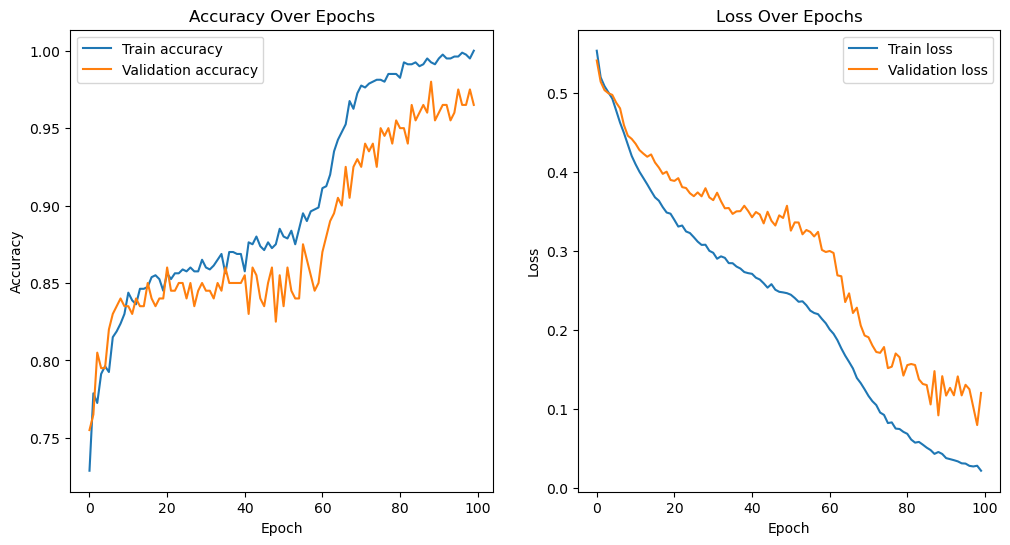

In [90]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(final_history.history['accuracy'],label="Train accuracy")
plt.plot(final_history.history['val_accuracy'],label="Validation accuracy")

plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1,2,2)
plt.plot(final_history.history['loss'],label="Train loss")
plt.plot(final_history.history['val_loss'],label="Validation loss")

plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

         

In [91]:
y_pred_final = final_model.predict(X_test_scaled)
y_pred_classes_final = (y_pred_final >0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


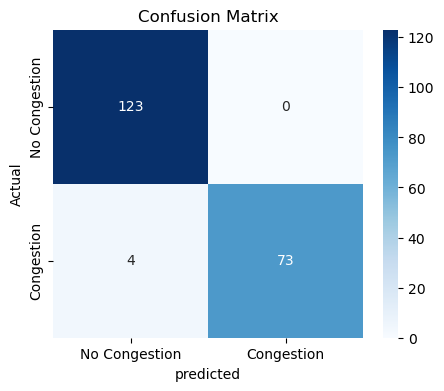

In [92]:
from sklearn.metrics import confusion_matrix, roc_curve , auc
import seaborn as sns
cm_final = confusion_matrix(y_test, y_pred_classes_final)
plt.figure(figsize=(5,4))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues",
           xticklabels=["No Congestion", "Congestion"],
           yticklabels=["No Congestion", "Congestion"])
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

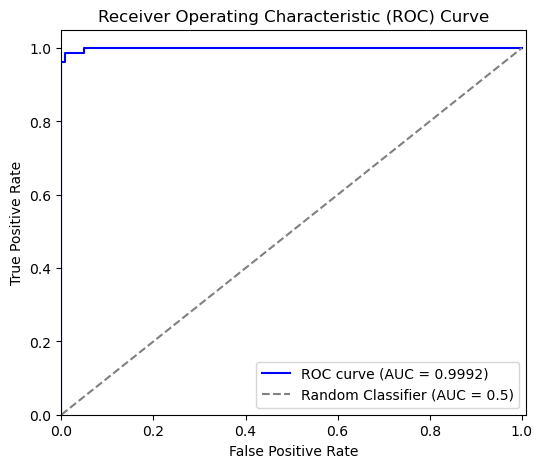

In [93]:
fpr_final, tpr_final, threshold_final = roc_curve(y_test, y_pred_final.ravel())
roc_auc_final = auc(fpr_final, tpr_final)

# Plot the ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr_final, tpr_final, label=f'ROC curve (AUC = {roc_auc_final:.4f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier (AUC = 0.5)")

# Formatting the plot
plt.xlim([0.0, 1.01])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

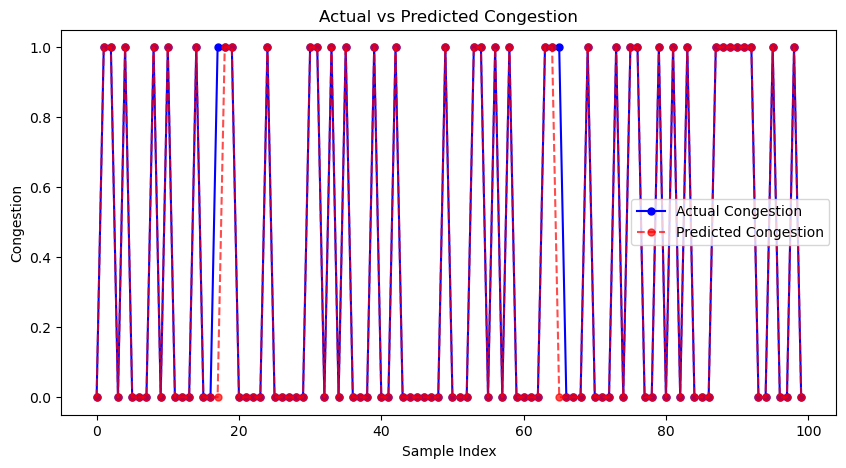

In [94]:
plt.figure(figsize=(10,5))
plt.plot(y_test[:100].reset_index(drop=True), 'bo-',  # Blue markers for actual
         label="Actual Congestion", markersize=5)
plt.plot(y_pred_classes_final[:100], 'ro--',  # Red dashed line for predicted
         label="Predicted Congestion", alpha=0.7, markersize=5)
plt.xlabel("Sample Index")
plt.ylabel("Congestion")
plt.title("Actual vs Predicted Congestion")
plt.legend() 
plt.show()